In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [3]:
df = pd.read_csv("../data/raw/student-por.csv", sep=";")

In [4]:
numerical_features = df.select_dtypes(include=["int64", "float64"]).columns
categorical_featues = df.select_dtypes(include=["object"]).columns
print("Numerical Features")
print(numerical_features)
print("\nCategorical Features")
print(categorical_featues)

Numerical Features
Index(['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel',
       'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2',
       'G3'],
      dtype='object')

Categorical Features
Index(['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
       'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
       'nursery', 'higher', 'internet', 'romantic'],
      dtype='object')


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,649.0,16.744222,1.218138,15.0,16.0,17.0,18.0,22.0
Medu,649.0,2.514638,1.134552,0.0,2.0,2.0,4.0,4.0
Fedu,649.0,2.306626,1.099931,0.0,1.0,2.0,3.0,4.0
traveltime,649.0,1.568567,0.748660,1.0,1.0,1.0,2.0,4.0
studytime,649.0,1.930663,0.829510,1.0,1.0,2.0,2.0,4.0
failures,649.0,0.221880,0.593235,0.0,0.0,0.0,0.0,3.0
famrel,649.0,3.930663,0.955717,1.0,4.0,4.0,5.0,5.0
freetime,649.0,3.180277,1.051093,1.0,3.0,3.0,4.0,5.0
goout,649.0,3.184900,1.175766,1.0,2.0,3.0,4.0,5.0
Dalc,649.0,1.502311,0.924834,1.0,1.0,1.0,2.0,5.0


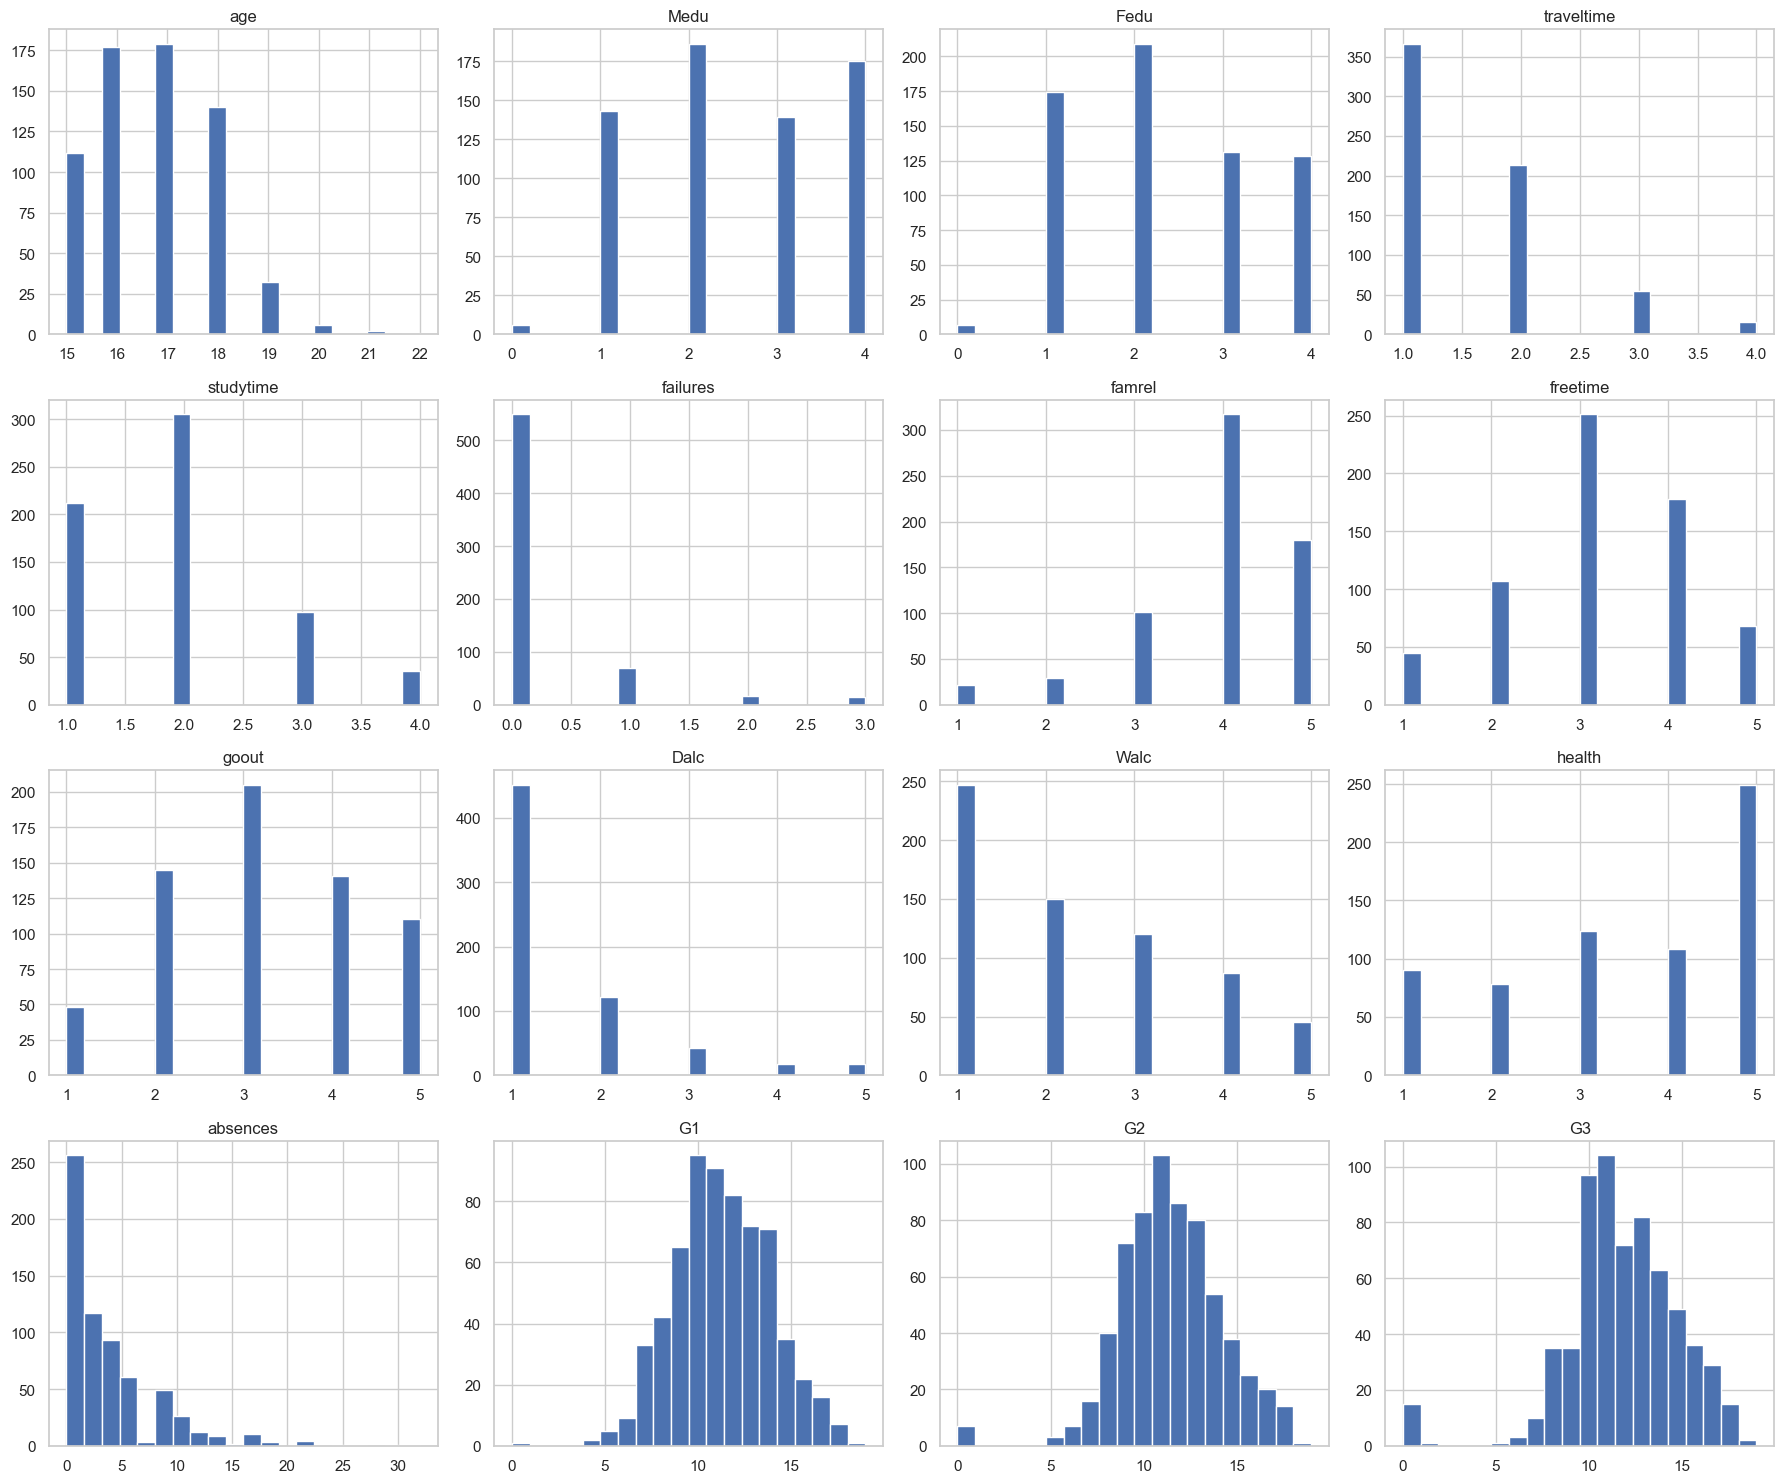

In [ ]:
#distribution of numerical features
df[numerical_features].hist(
    figsize=(18, 15),
    bins=20
)
plt.tight_layout()
plt.show()

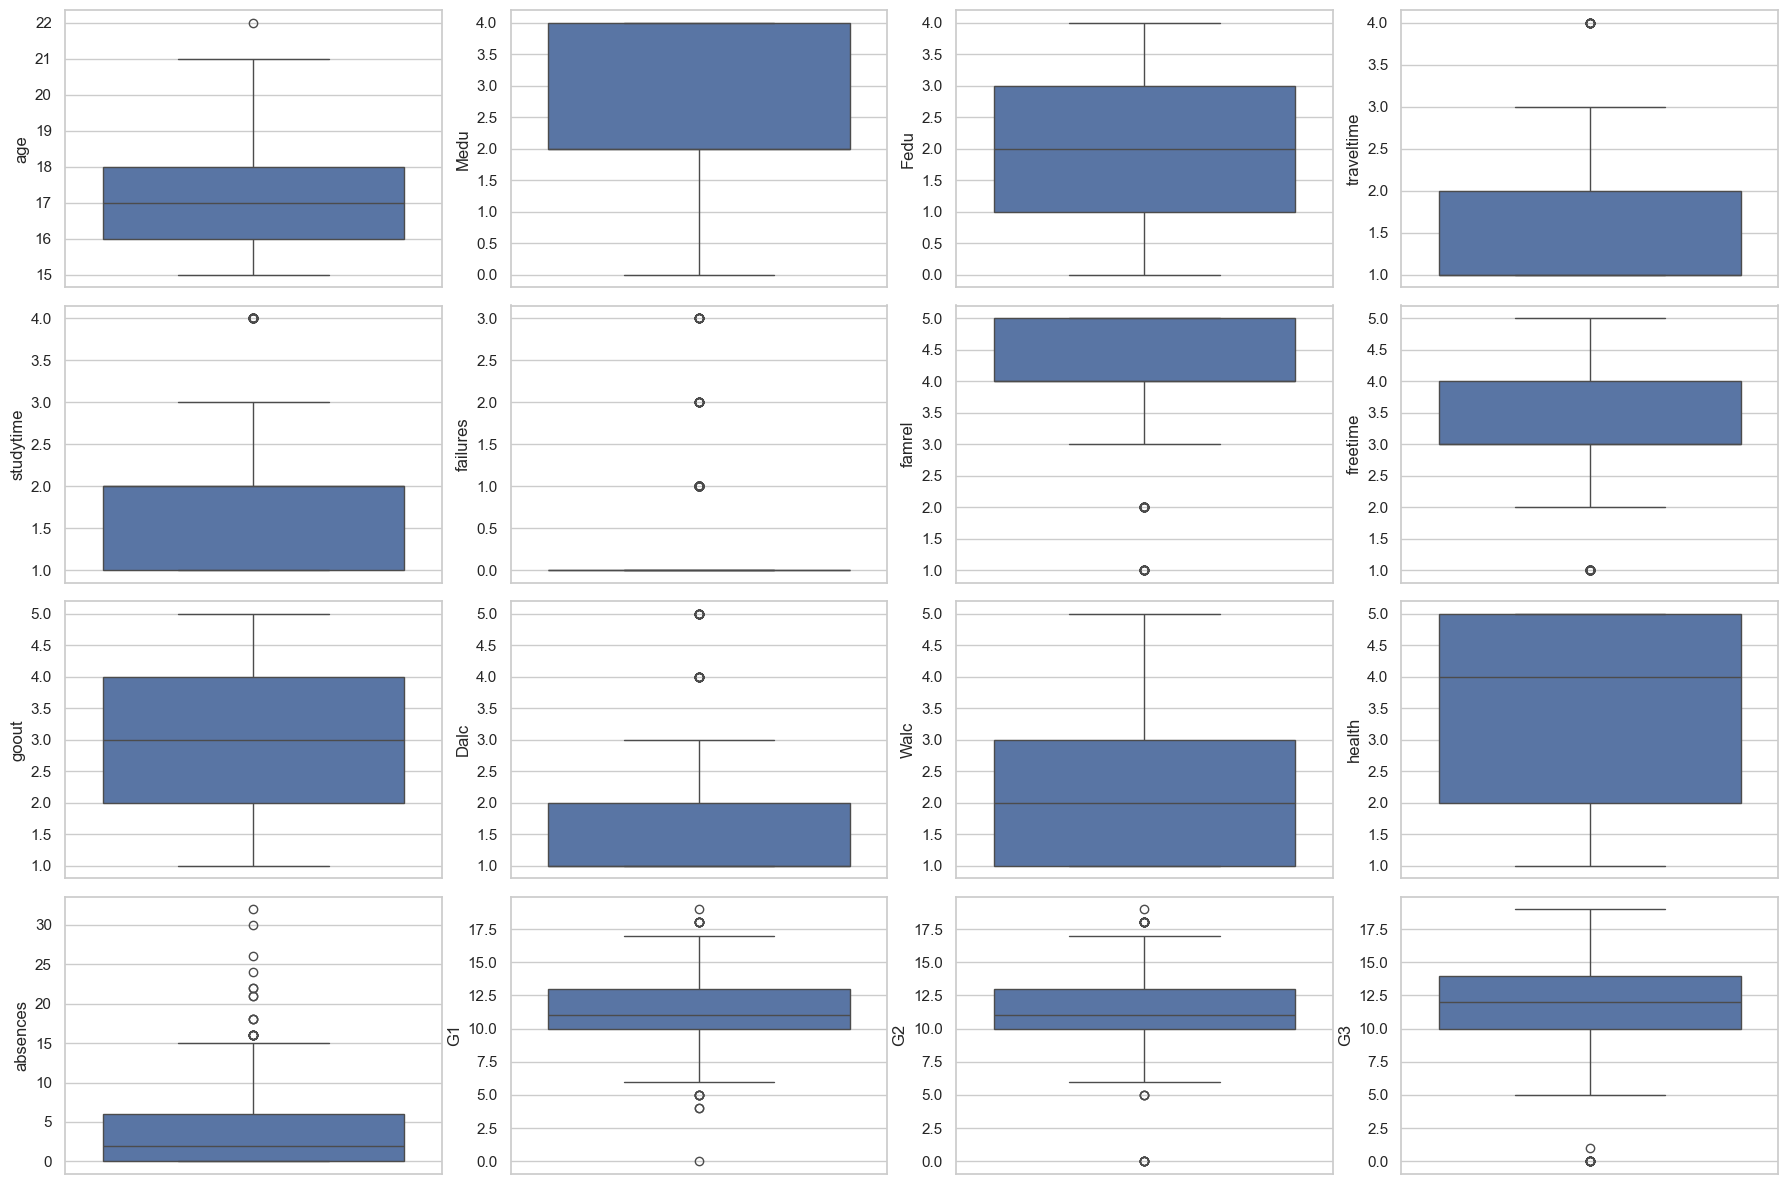

In [7]:
#boxplots
plt.figure(figsize=(18,12))
for i, column in enumerate(numerical_features):
    plt.subplot(4,4,i+1)
    sns.boxplot(y=df[column])
plt.tight_layout()
plt.show()

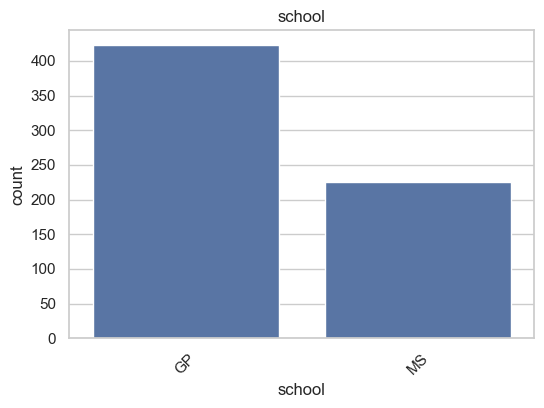

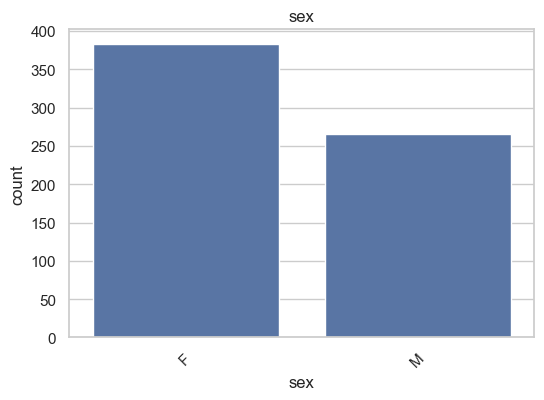

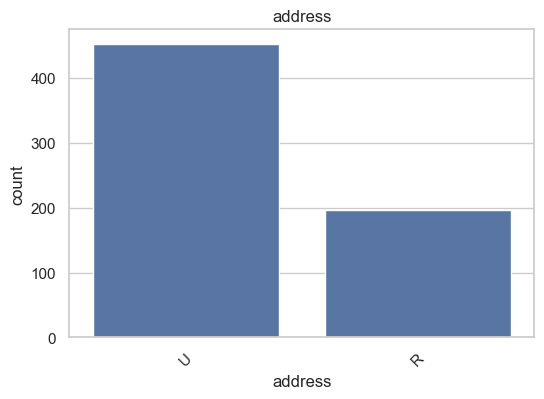

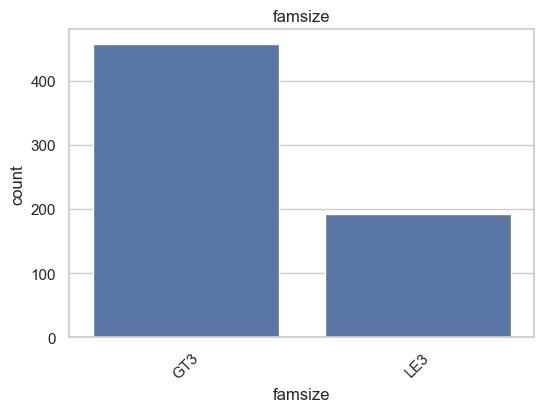

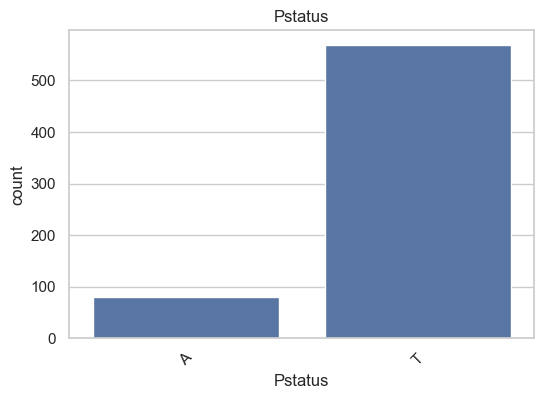

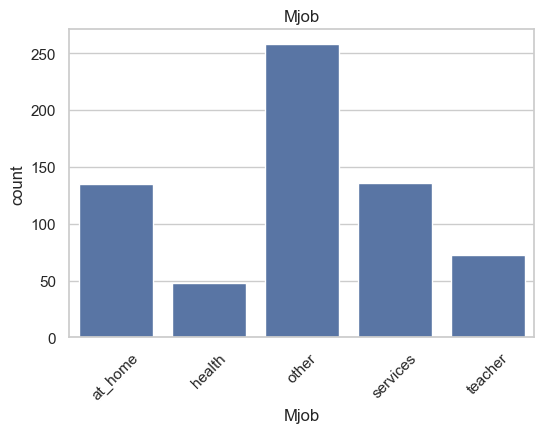

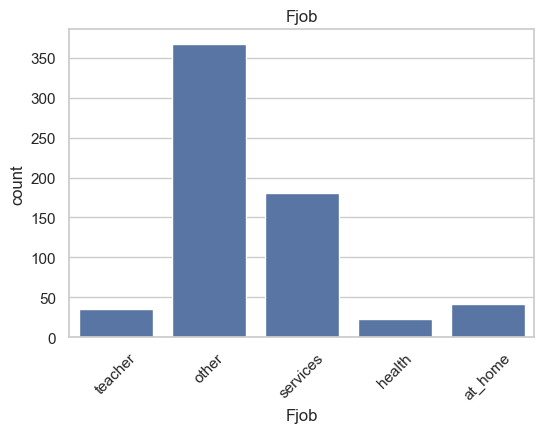

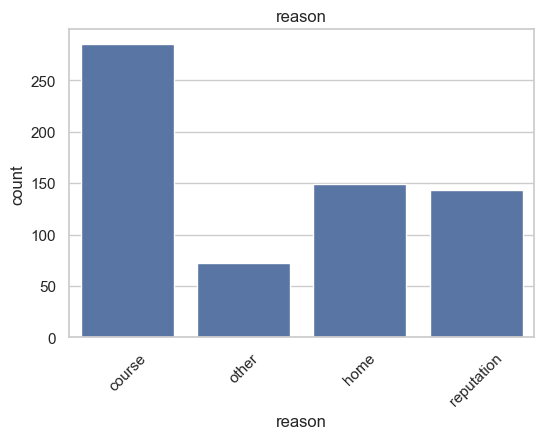

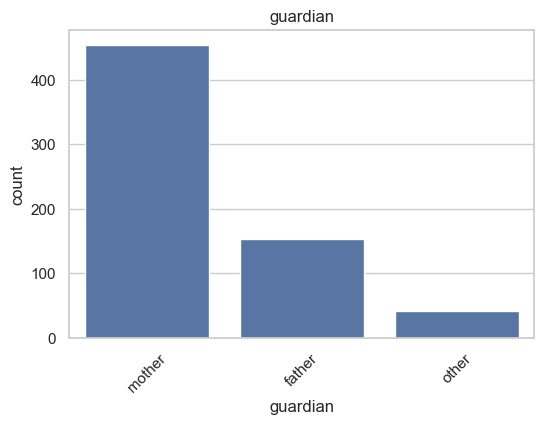

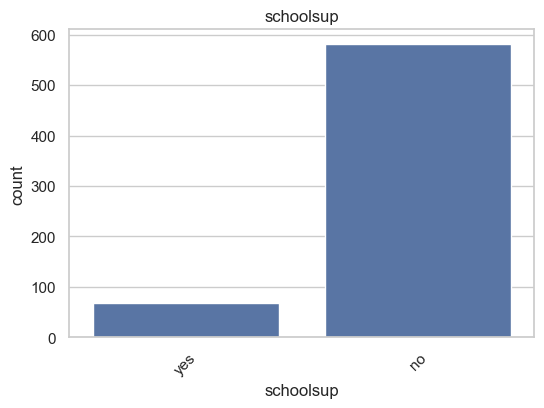

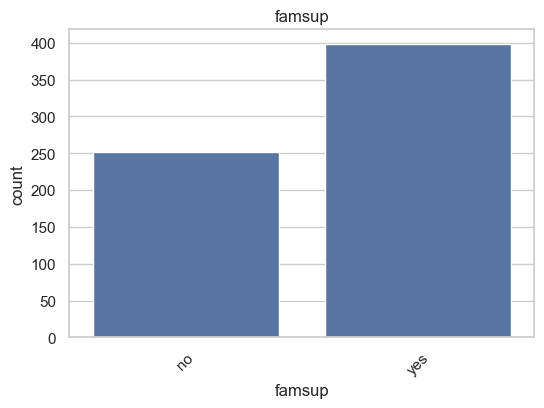

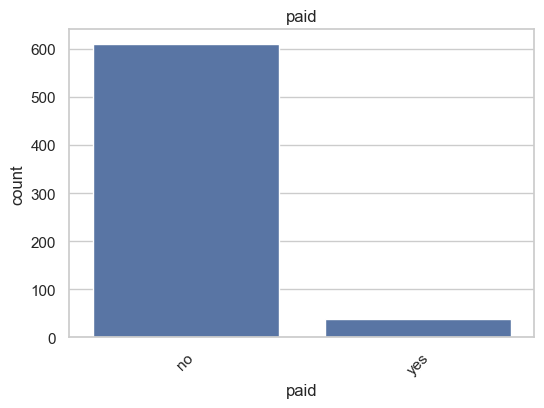

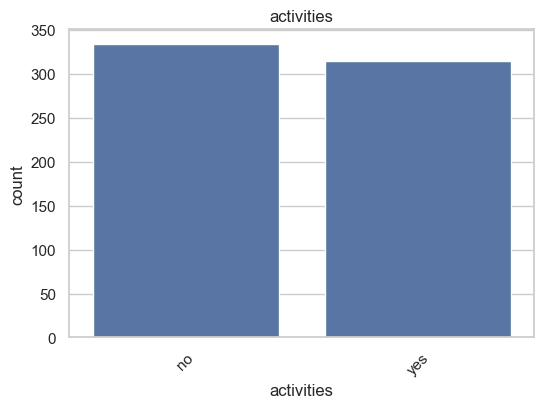

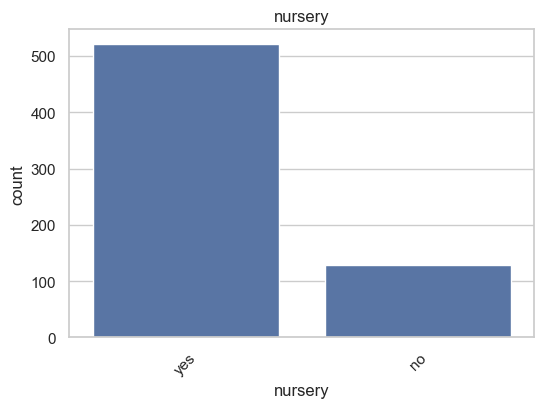

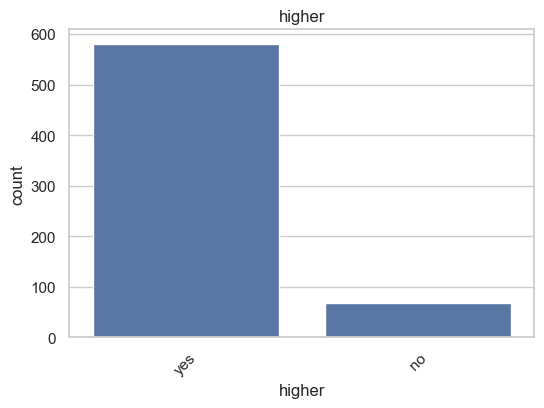

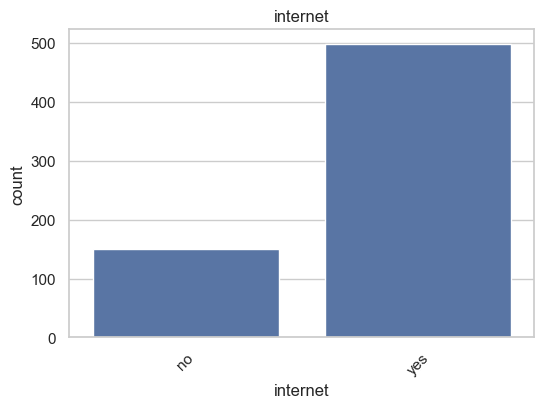

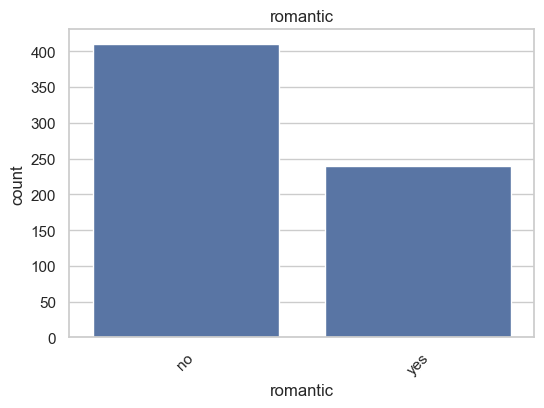

In [8]:
#categorical feature distribution
for column in categorical_featues:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=column)
    plt.xticks(rotation=45)
    plt.title(column)
    plt.show()

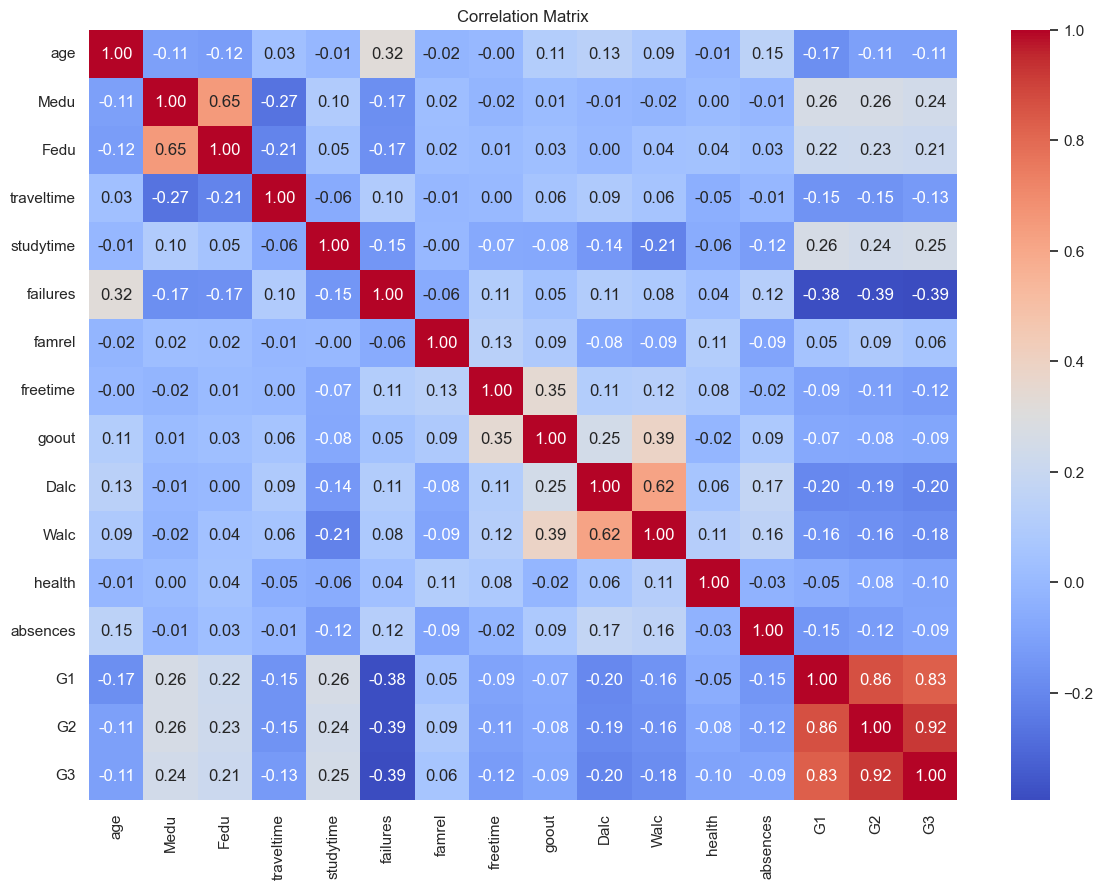

In [9]:
correlation = df.corr(numeric_only=True)
plt.figure(figsize=(14,10))
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Matrix")
plt.show()

In [10]:
correlation["G3"].sort_values(ascending=False)

G3            1.000000
G2            0.918548
G1            0.826387
studytime     0.249789
Medu          0.240151
Fedu          0.211800
famrel        0.063361
goout        -0.087641
absences     -0.091379
health       -0.098851
age          -0.106505
freetime     -0.122705
traveltime   -0.127173
Walc         -0.176619
Dalc         -0.204719
failures     -0.393316
Name: G3, dtype: float64

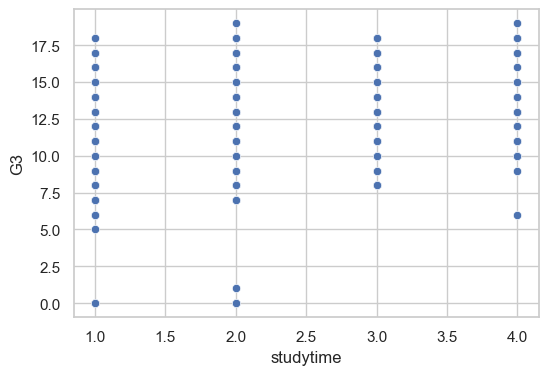

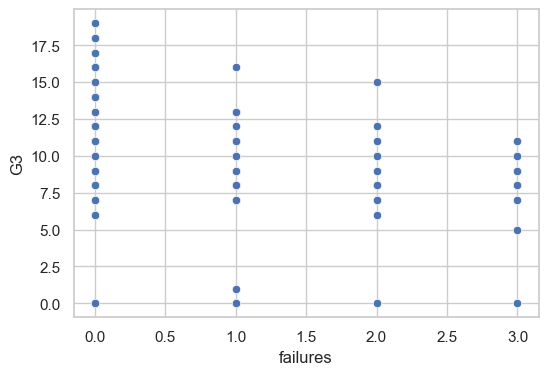

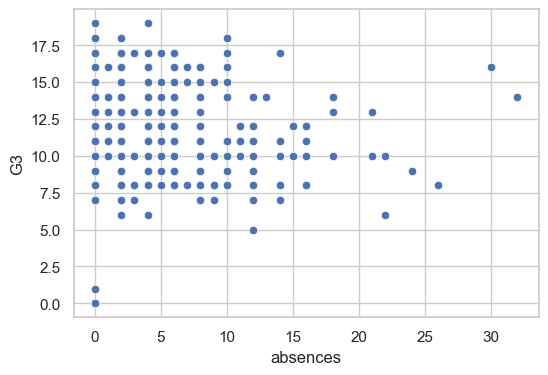

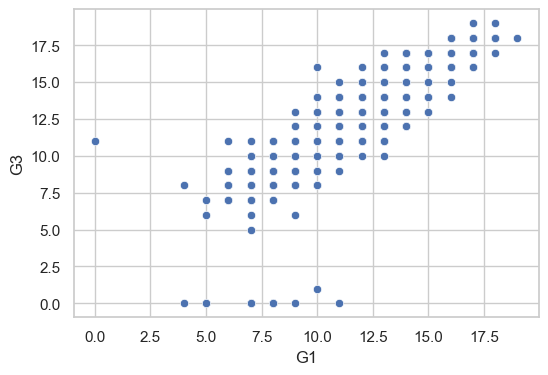

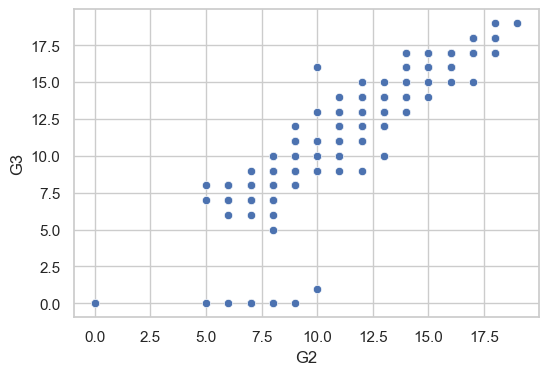

In [11]:
important_features = ["studytime","failures","absences","G1","G2"]
for feature in important_features:
    plt.figure(figsize=(6,4))
    sns.scatterplot(
        data=df,
        x=feature,
        y="G3"
    )
    plt.show()

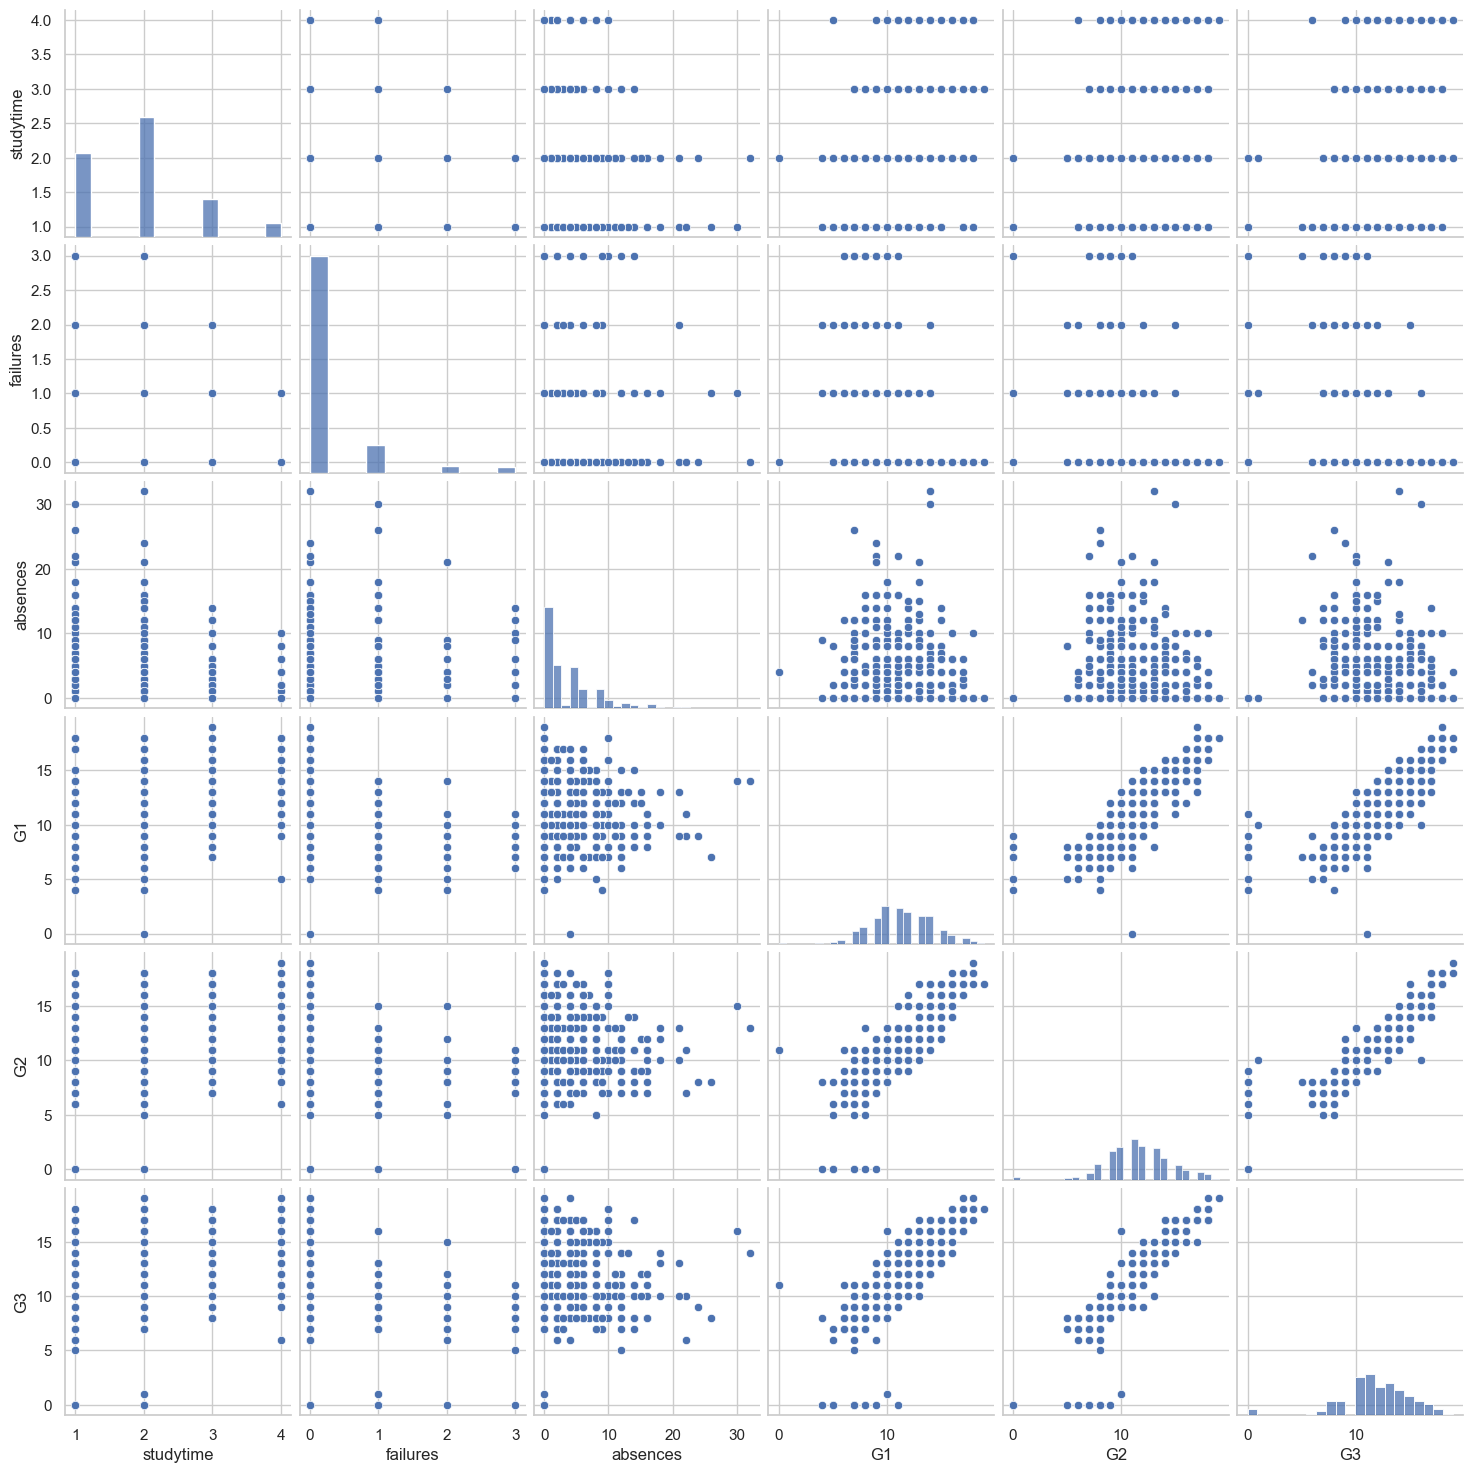

In [12]:
sns.pairplot(
    df[
        ["studytime",
         "failures",
         "absences",
         "G1",
         "G2",
         "G3"]
    ]
)
plt.show()